In [ ]:
./scripts/manage_experiment.py --config exp_conf/pb_child_pf_eval.ini --build --run 

In [24]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/pb_child_pf_eval.ini --parse

/home/bscuser/synched_mnt/VMem
Preprocessing configuration file...
['rsync', '-avz', '--no-checksum', '--ignore-errors', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.bsc.es:/gpfs/scratch/bsc18/bsc018186/VMem/data/pb_child_pf_eval/BASELINE', './data/pb_child_pf_eval']
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list

sent 51 bytes  received 4,218 bytes  8,538.00 bytes/sec
total size is 2,336,247  speedup is 547.26
Parsing results for BASELINE...
Merging results to ./stats/pb_child_pf_eval/BASELINE/selected_qualcomm_srv_ap_BASELINE.csv
Parsing completed successfully
['rsync', '-avz', '--no-checksum', '--ignore-errors', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.bsc.es:/gpfs/scratch/bsc18/bsc018186/VMem/d

/home/bscuser/synched_mnt/VMem
Preprocessing configuration file...
['BASELINE', 'pb-l1d_child_ideal_pf', 'pb-l2c_child_ideal_pf', 'pb-llc_child_ideal_pf']
Plotting pb_child_pf_eval for selected_qualcomm_srv_ap
['BASELINE', 'PF_L1D-F_L1D', 'PF_L1D-F_L2C', 'PF_L1D-F_LLC']
            tag  IPC_IMPROVEMENT
0  PF_L1D-F_L1D         4.955335
1  PF_L1D-F_L2C         2.553878
2  PF_L1D-F_LLC         1.545713
PF_L1D-F_L1D:5.132416174780593
PF_L1D-F_L2C:3.407596715382942
PF_L1D-F_LLC:1.942719856178247
  benchmarks           tag      mean
0       mean  PF_L1D-F_L1D  5.132416
1       mean  PF_L1D-F_L2C  3.407597
2       mean  PF_L1D-F_LLC  1.942720
  benchmarks           tag      mean
0       mean  PF_L1D-F_L1D  5.132416
1       mean  PF_L1D-F_L2C  3.407597
2       mean  PF_L1D-F_LLC  1.942720
./figures/pb_child_pf_eval/pb_child_pf_eval_ipc_selected_qualcomm_srv_ap.png
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is

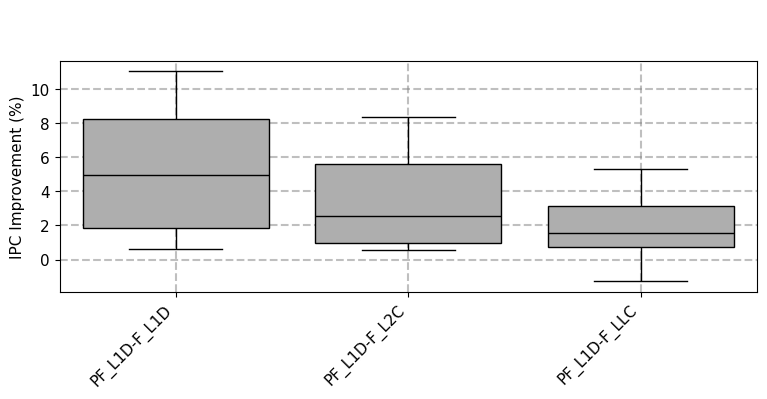

In [13]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/pb_child_pf_eval.ini --plot
from IPython.display import Image, display
display(Image("./figures/pb_child_pf_eval/pb_child_pf_eval_ipc_selected_qualcomm_srv_ap.png", 
width=600, height=600))

# Analysis

/home/bscuser/synched_mnt/VMem


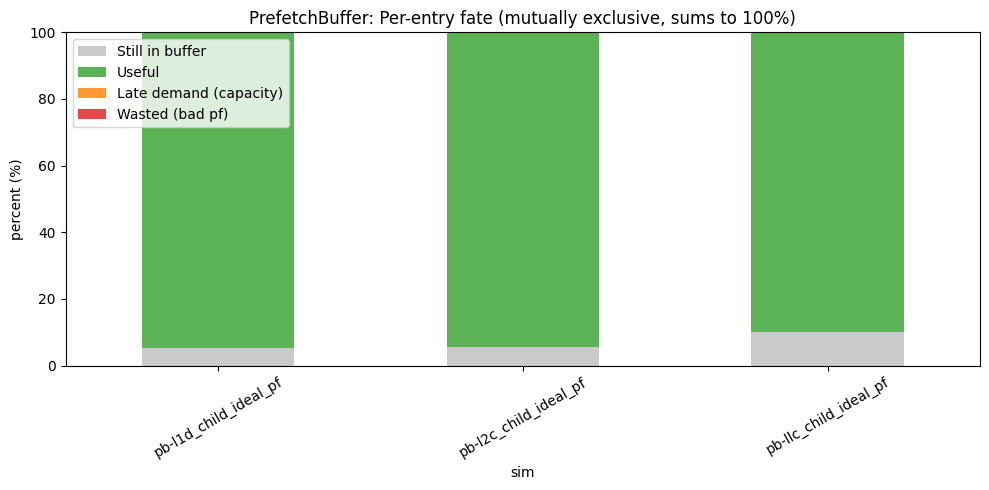


Per-entry fate percentages (sum should = 100%):
                       still_pct  evicted_used_pct  late_pct  waste_pct  \
sim                                                                       
pb-l1d_child_ideal_pf        5.3              94.4       0.2        0.1   
pb-l2c_child_ideal_pf        5.6              94.2       0.1        0.1   
pb-llc_child_ideal_pf       10.2              89.5       0.2        0.1   

                       sum_pct  
sim                             
pb-l1d_child_ideal_pf    100.0  
pb-l2c_child_ideal_pf    100.0  
pb-llc_child_ideal_pf    100.0  

Useful access rate (may be >100% if entries hit multiple times):
                       useful_pct
sim                              
pb-l1d_child_ideal_pf        97.2
pb-l2c_child_ideal_pf        94.0
pb-llc_child_ideal_pf        89.3


In [14]:
# Parse PREFETCH_BUFFER lines from raw .out files and plot complete breakdown
%cd /home/bscuser/synched_mnt/VMem
import re, glob
import pandas as pd
import matplotlib.pyplot as plt

# Color scheme (consistent)
colors = {
    'useful': '#33a02c',       # green
    'evicted_used': '#6baed6', # blue  
    'still': '#bdbdbd',        # gray
    'late': '#ff7f00',         # orange
    'true_waste': '#e31a1c'    # red
}

exp = 'pb_child_pf_eval'
sims = ['pb-l1d_child_ideal_pf', 'pb-l2c_child_ideal_pf', 'pb-llc_child_ideal_pf']
data_dir = f"data/{exp}"

# Regex to match PREFETCH_BUFFER line with all stats
pat = re.compile(r'^(?P<cache>\S+)\s+PREFETCH_BUFFER.*?INSERTS:\s*(?P<inserts>\d+).*?USEFUL:\s*(?P<useful>\d+).*?USELESS:\s*(?P<useless>\d+).*?LATE_DEMAND:\s*(?P<late>\d+).*?SIZE_AT_END:\s*(?P<size>\d+)', re.MULTILINE | re.DOTALL)

rows = []
for sim in sims:
    files = sorted(glob.glob(f"{data_dir}/{sim}/*_run.out"))
    acc = {'inserts':0, 'useful':0, 'useless':0, 'late':0, 'size_end':0}
    found = 0
    for fpath in files:
        try:
            txt = open(fpath,'r', errors='ignore').read()
        except Exception:
            continue
        m = pat.search(txt)
        if m:
            found += 1
            acc['inserts'] += int(m.group('inserts'))
            acc['useful'] += int(m.group('useful'))
            acc['useless'] += int(m.group('useless'))
            acc['late'] += int(m.group('late'))
            acc['size_end'] += int(m.group('size'))
    rows.append({'sim': sim, **acc, 'found_files': len(files), 'matched_files': found})

df = pd.DataFrame(rows).set_index('sim')

# Compute per-entry fate percentages (mutually exclusive)
def pct(num, denom):
    return (100.0 * num / denom) if denom and denom > 0 else 0.0

# Per-entry fates (mutually exclusive, sum to 100%):
# 1. Still in buffer at end
df['still_pct'] = df.apply(lambda r: pct(r['size_end'], r['inserts']), axis=1)
# 2. Evicted after being used (inserts - still - useless)
df['evicted_used_pct'] = df.apply(lambda r: pct(r['inserts'] - r['size_end'] - r['useless'], r['inserts']), axis=1)
# 3. Evicted unused, later demanded (late demand capacity issue)
df['late_pct'] = df.apply(lambda r: pct(r['late'], r['inserts']), axis=1)
# 4. Evicted unused, never demanded (true waste)
df['waste_pct'] = df.apply(lambda r: pct(r['useless'] - r['late'], r['inserts']), axis=1)

# Also compute useful access rate (may be > 100% if entries hit multiple times)
df['useful_pct'] = df.apply(lambda r: pct(r['useful'], r['inserts']), axis=1)

# Mutually-exclusive stacked fate
stacked_cols = ['still_pct', 'evicted_used_pct', 'late_pct', 'waste_pct']
df['sum_pct'] = df[stacked_cols].sum(axis=1)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10,5))

df[stacked_cols].plot(kind='bar', stacked=True, ax=ax,
    color=[colors['still'], colors['useful'], colors['late'], colors['true_waste']], alpha=0.8)
ax.set_ylabel('percent (%)')
ax.set_ylim(0,100)
ax.set_title('PrefetchBuffer: Per-entry fate (mutually exclusive, sums to 100%)')
ax.legend(['Still in buffer', 'Useful', 'Late demand (capacity)', 'Wasted (bad pf)'], loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30)

plt.tight_layout()
plt.show()

# Print table
pd.options.display.float_format = '{:0.1f}'.format
print("\nPer-entry fate percentages (sum should = 100%):")
print(df[['still_pct', 'evicted_used_pct', 'late_pct', 'waste_pct', 'sum_pct']])
print("\nUseful access rate (may be >100% if entries hit multiple times):")
print(df[['useful_pct']])


***

In [ ]:
./scripts/manage_experiment.py --config exp_conf/pb_child_pf_size_impact.ini --build --run

In [21]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/pb_child_pf_size_impact.ini --parse

/home/bscuser/synched_mnt/VMem
Preprocessing configuration file...
['rsync', '-avz', '--no-checksum', '--ignore-errors', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.bsc.es:/gpfs/scratch/bsc18/bsc018186/VMem/data/pb_child_pf_eval/BASELINE', './data/pb_child_pf_eval']
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list

sent 51 bytes  received 4,218 bytes  8,538.00 bytes/sec
total size is 2,336,247  speedup is 547.26
Parsing results for BASELINE...
Merging results to ./stats/pb_child_pf_eval/BASELINE/selected_qualcomm_srv_ap_BASELINE.csv
Parsing completed successfully
['rsync', '-avz', '--no-checksum', '--ignore-errors', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.bsc.es:/gpfs/scratch/bsc18/bsc018186/VMem/d

/home/bscuser/synched_mnt/VMem
Override applied: PLOTTING.file_type='pdf'
Preprocessing configuration file...
['BASELINE', 'pb-s16-w16-l1d_child_ideal_pf', 'pb-s32-w16-l1d_child_ideal_pf', 'pb-s64-w16-l1d_child_ideal_pf', 'pb-s128-w16-l1d_child_ideal_pf', 'pb-s512-w16-l1d_child_ideal_pf', 'pb-s4096-w16-l1d_child_ideal_pf', 'pb-s16-w16-l2c_child_ideal_pf', 'pb-s32-w16-l2c_child_ideal_pf', 'pb-s64-w16-l2c_child_ideal_pf', 'pb-s128-w16-l2c_child_ideal_pf', 'pb-s512-w16-l2c_child_ideal_pf', 'pb-s4096-w16-l2c_child_ideal_pf', 'pb-s16-w16-llc_child_ideal_pf', 'pb-s32-w16-llc_child_ideal_pf', 'pb-s64-w16-llc_child_ideal_pf', 'pb-s128-w16-llc_child_ideal_pf', 'pb-s512-w16-llc_child_ideal_pf', 'pb-s4096-w16-llc_child_ideal_pf']
Plotting pb_child_pf_size_impact for selected_qualcomm_srv_ap
['BASELINE', 'L1-16KB', 'L1-32KB', 'L1-64KB', 'L1-128KB', 'L1-512KB', 'L1-Unlimited', 'L2-16KB', 'L2-32KB', 'L2-64KB', 'L2-128KB', 'L2-512KB', 'L2-Unlimited', 'LLC-16KB', 'LLC-32KB', 'LLC-64KB', 'LLC-128KB', '

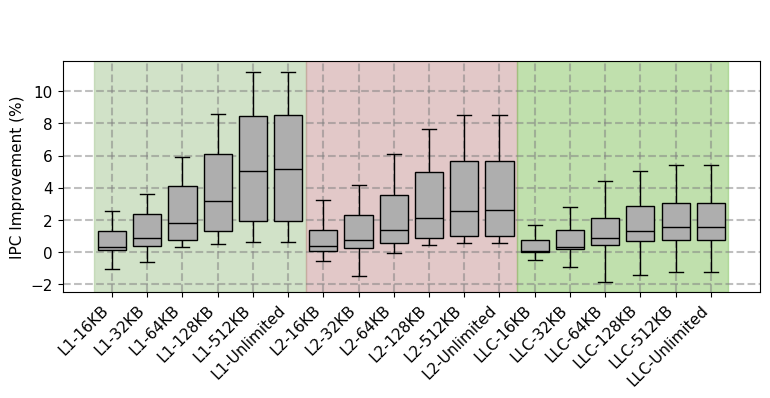

In [33]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/pb_child_pf_size_impact.ini --plot --override "PLOTTING.file_type=pdf"
from IPython.display import Image, display
display(Image("./figures/pb_child_pf_eval/pb_child_pf_size_impact_ipc_selected_qualcomm_srv_ap.png", 
width=600, height=600))

/home/bscuser/synched_mnt/VMem
Processing 18 configurations from pb_child_pf_size_impact.ini


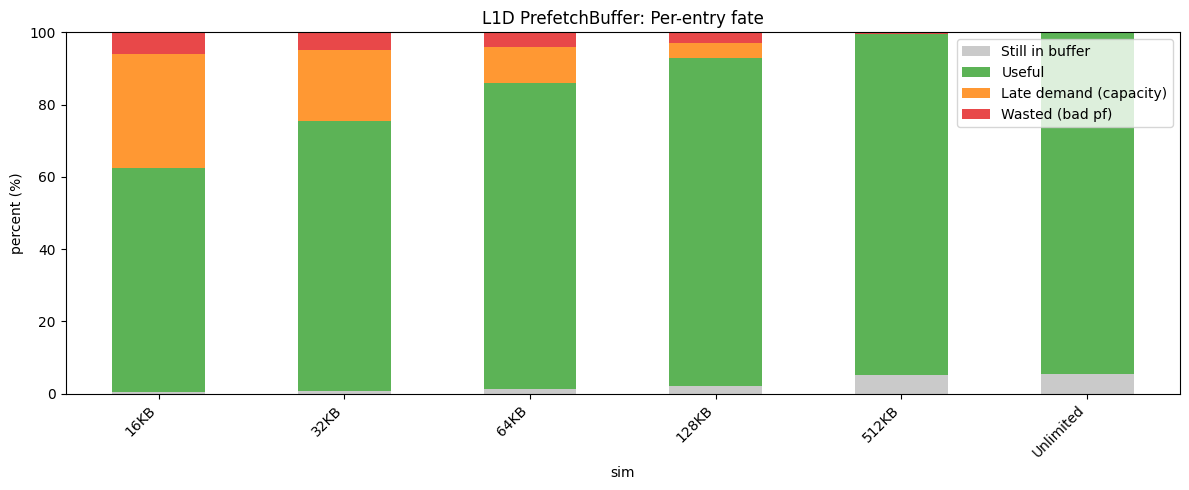

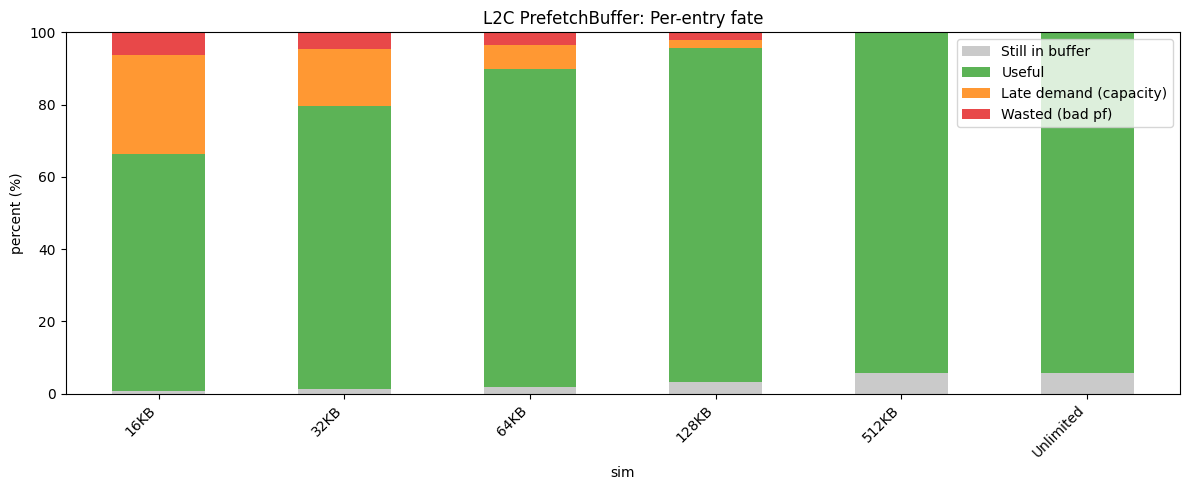

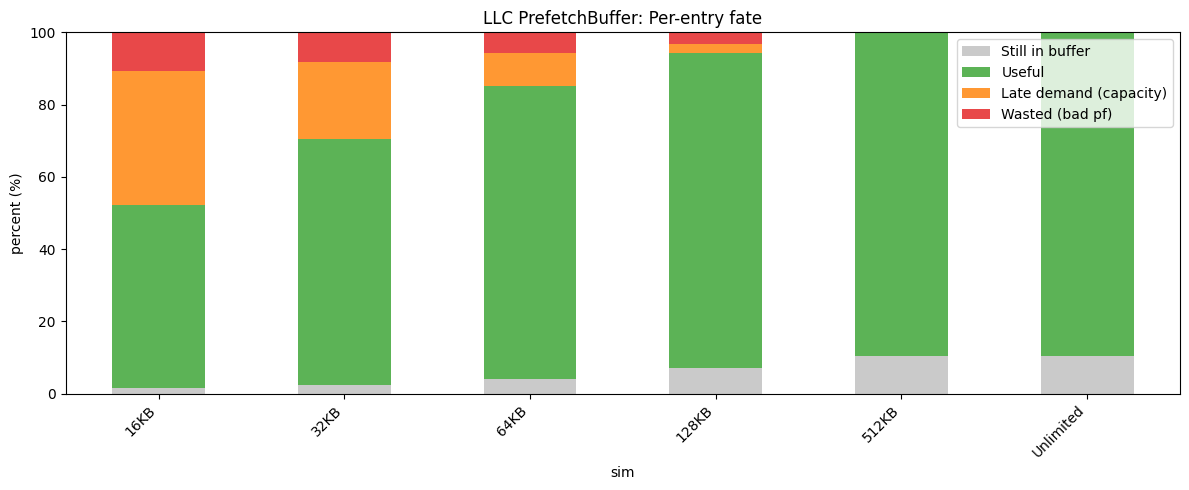


Summary: per-entry fate (sum_pct should = 100%):
                                 sets  still_pct  evicted_used_pct  late_pct  \
sim                                                                            
pb-s16-w16-l1d_child_ideal_pf      16        0.4              62.0      31.5   
pb-s16-w16-llc_child_ideal_pf      16        1.5              50.6      37.2   
pb-s16-w16-l2c_child_ideal_pf      16        0.7              65.6      27.5   
pb-s32-w16-l1d_child_ideal_pf      32        0.7              74.6      19.7   
pb-s32-w16-llc_child_ideal_pf      32        2.5              67.9      21.4   
pb-s32-w16-l2c_child_ideal_pf      32        1.2              78.4      15.8   
pb-s64-w16-llc_child_ideal_pf      64        4.1              80.9       9.1   
pb-s64-w16-l2c_child_ideal_pf      64        1.9              87.9       6.7   
pb-s64-w16-l1d_child_ideal_pf      64        1.2              84.7      10.1   
pb-s128-w16-l2c_child_ideal_pf    128        3.2              92.4    

In [32]:
# Parse PREFETCH_BUFFER stats for pb_child_pf_size_impact (per-entry fate breakdown)
# This processes the size-impact configurations from pb_child_pf_size_impact.ini
%cd /home/bscuser/synched_mnt/VMem
import re, glob, os
import pandas as pd
import matplotlib.pyplot as plt

# Color scheme (consistent)
colors = {
    'useful': '#33a02c',       # green
    'evicted_used': '#6baed6', # blue  
    'still': '#bdbdbd',        # gray
    'late': '#ff7f00',         # orange
    'true_waste': '#e31a1c'    # red
}

# Data is stored under pb_child_pf_eval (experiment name from config)
exp = 'pb_child_pf_eval'
data_dir = f"data/{exp}"

# Hardcoded configurations from pb_child_pf_size_impact.ini
# Sets: 16, 32, 64, 128, 512, 4096 with ways=16 for each cache level
sim_dirs = [
    'pb-s16-w16-l1d_child_ideal_pf', 'pb-s32-w16-l1d_child_ideal_pf', 'pb-s64-w16-l1d_child_ideal_pf', 
    'pb-s128-w16-l1d_child_ideal_pf', 'pb-s512-w16-l1d_child_ideal_pf', 
    'pb-s4096-w16-l1d_child_ideal_pf',
    'pb-s16-w16-l2c_child_ideal_pf', 'pb-s32-w16-l2c_child_ideal_pf', 'pb-s64-w16-l2c_child_ideal_pf', 
    'pb-s128-w16-l2c_child_ideal_pf', 'pb-s512-w16-l2c_child_ideal_pf', 
    'pb-s4096-w16-l2c_child_ideal_pf',
    'pb-s16-w16-llc_child_ideal_pf', 'pb-s32-w16-llc_child_ideal_pf', 'pb-s64-w16-llc_child_ideal_pf', 
    'pb-s128-w16-llc_child_ideal_pf', 'pb-s512-w16-llc_child_ideal_pf', 
    'pb-s4096-w16-llc_child_ideal_pf'
]
print(f"Processing {len(sim_dirs)} configurations from pb_child_pf_size_impact.ini")

# Regex to match PREFETCH_BUFFER line
pat = re.compile(r'^(?P<cache>\S+)\s+PREFETCH_BUFFER.*?INSERTS:\s*(?P<inserts>\d+).*?USEFUL:\s*(?P<useful>\d+).*?USELESS:\s*(?P<useless>\d+).*?LATE_DEMAND:\s*(?P<late>\d+).*?SIZE_AT_END:\s*(?P<size>\d+)', re.MULTILINE | re.DOTALL)

rows = []
for sim in sim_dirs:
    files = sorted(glob.glob(f"{data_dir}/{sim}/*_run.out"))
    acc = {'inserts':0, 'useful':0, 'useless':0, 'late':0, 'size_end':0}
    found = 0
    for fpath in files:
        try:
            txt = open(fpath,'r', errors='ignore').read()
        except Exception:
            continue
        m = pat.search(txt)
        if m:
            found += 1
            acc['inserts'] += int(m.group('inserts'))
            acc['useful'] += int(m.group('useful'))
            acc['useless'] += int(m.group('useless'))
            acc['late'] += int(m.group('late'))
            acc['size_end'] += int(m.group('size'))
    if found > 0:
        rows.append({'sim': sim, **acc})

if len(rows) == 0:
    print("No PREFETCH_BUFFER data found!")
else:
    df = pd.DataFrame(rows).set_index('sim')
    
    # Extract sets and sort
    df['sets'] = df.index.to_series().str.extract(r's(\d+)', expand=False).fillna('-1').astype(int)
    df.sort_values('sets', inplace=True)
    
    # Compute per-entry fate percentages (mutually exclusive)
    def pct(num, denom):
        return (100.0 * num / denom) if denom and denom > 0 else 0.0
    
    # Per-entry fates (mutually exclusive, sum to 100%):
    # 1. Still in buffer at end
    df['still_pct'] = df.apply(lambda r: pct(r['size_end'], r['inserts']), axis=1)
    # 2. Evicted after being used (inserts - still - useless)
    df['evicted_used_pct'] = df.apply(lambda r: pct(r['inserts'] - r['size_end'] - r['useless'], r['inserts']), axis=1)
    # 3. Evicted unused, later demanded (late demand = capacity issue)
    df['late_pct'] = df.apply(lambda r: pct(r['late'], r['inserts']), axis=1)
    # 4. Evicted unused, never demanded (true waste)
    df['waste_pct'] = df.apply(lambda r: pct(r['useless'] - r['late'], r['inserts']), axis=1)
    
    # Also compute useful access rate (may be > 100% if entries hit multiple times)
    df['useful_pct'] = df.apply(lambda r: pct(r['useful'], r['inserts']), axis=1)
    
    # Mutually-exclusive stacked fate
    stacked_cols = ['still_pct', 'evicted_used_pct', 'late_pct', 'waste_pct']
    df['sum_pct'] = df[stacked_cols].sum(axis=1)
    
    # Compute size in KB: sets * 16 * 64 / 1024
    df['size_kb'] = (df['sets'] * 16 * 64 / 1024).astype(int)
    
    # Separate by cache level
    df_l1d = df[df.index.str.contains('l1d')]
    df_l2c = df[df.index.str.contains('l2c')]
    df_llc = df[df.index.str.contains('llc')]
    
    # Plot each cache level separately
    for cache_level, df_subset in [('L1D', df_l1d), ('L2C', df_l2c), ('LLC', df_llc)]:
        if len(df_subset) == 0:
            continue
            
        fig, ax = plt.subplots(1, 1, figsize=(12,5))
        
        # Per-entry fate breakdown (sums to 100%)
        df_subset[stacked_cols].plot(
            kind='bar', stacked=True, ax=ax, 
            color=[colors['still'], colors['useful'], colors['late'], colors['true_waste']], alpha=0.8)
        ax.set_ylabel('percent (%)')
        ax.set_ylim(0,100)
        ax.set_title(f'{cache_level} PrefetchBuffer: Per-entry fate')
        ax.legend(['Still in buffer', 'Useful', 'Late demand (capacity)', 'Wasted (bad pf)'], loc='upper right')
        ax.set_xticklabels(["Unlimited" if int(row['size_kb']) == 4096 else f"{int(row['size_kb'])}KB" for _, row in df_subset.iterrows()], rotation=45, ha='right')
        
        plt.tight_layout()
        
        # Save figure
        os.makedirs('figures/pb_child_pf_size_impact', exist_ok=True)
        fig.savefig(f'figures/pb_child_pf_size_impact/pb_fate_{cache_level.lower()}.pdf', dpi=300, bbox_inches='tight')
        
        plt.show()
    
    # Print summary
    pd.options.display.float_format = '{:0.1f}'.format
    print(f"\nSummary: per-entry fate (sum_pct should = 100%):")
    print(df[['sets', 'still_pct', 'evicted_used_pct', 'late_pct', 'waste_pct', 'sum_pct']])

    print(f"\nUseful access rate (may exceed 100% if entries are hit multiple times):")
    print(df[['sets', 'useful_pct']])